In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('E:\projects\Medical Insurance Analysis\data\medical_insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.shape

(2772, 7)

In [6]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(1435)

In [13]:
df = df.drop_duplicates()

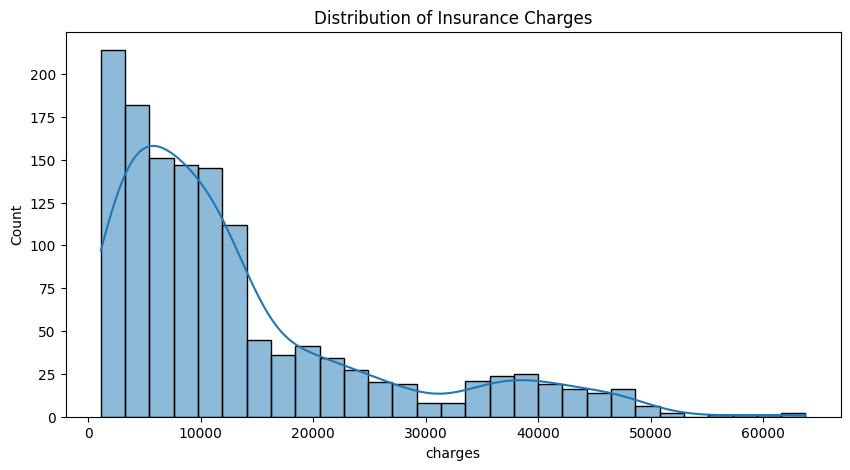

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["charges"],
    kde=True
)

plt.title("Distribution of Insurance Charges")

plt.show()

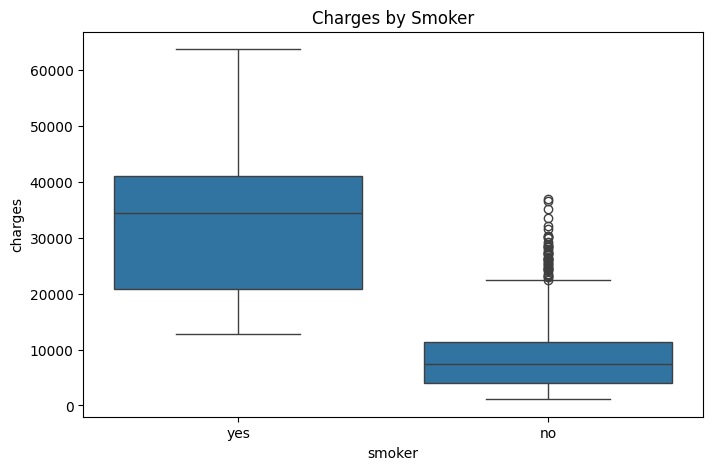

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="smoker",
    y="charges",
    data=df
)

plt.title("Charges by Smoker")

plt.show()

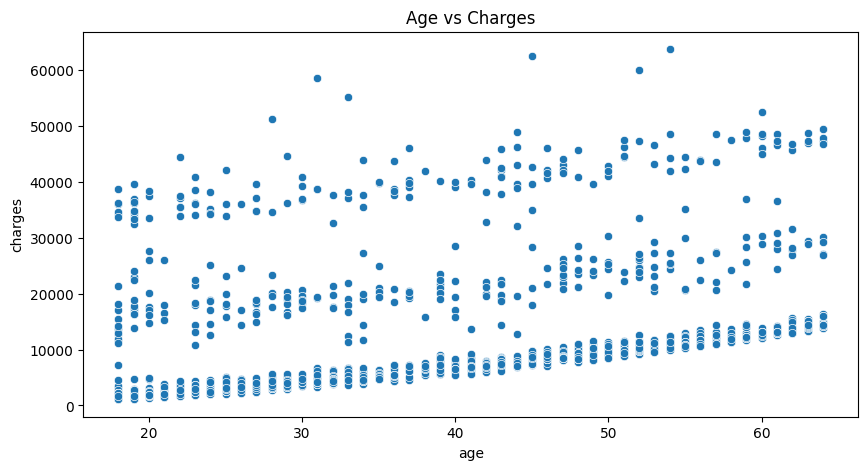

In [16]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x="age",
    y="charges",
    data=df
)

plt.title("Age vs Charges")

plt.show()

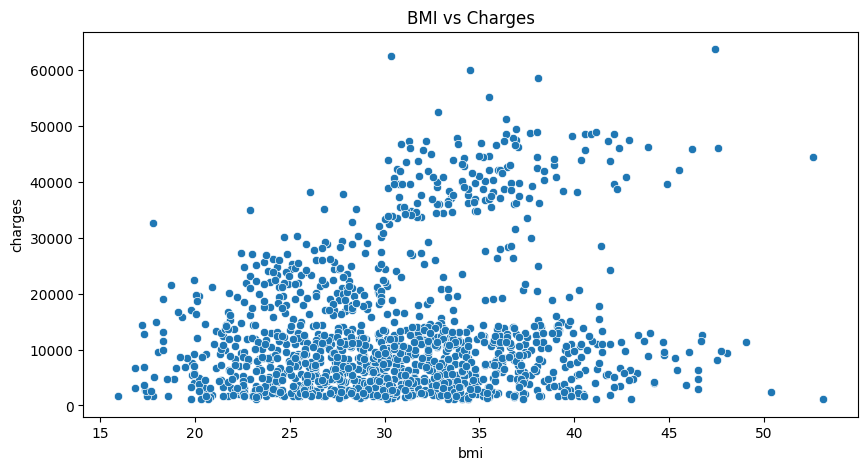

In [17]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x="bmi",
    y="charges",
    data=df
)

plt.title("BMI vs Charges")

plt.show()

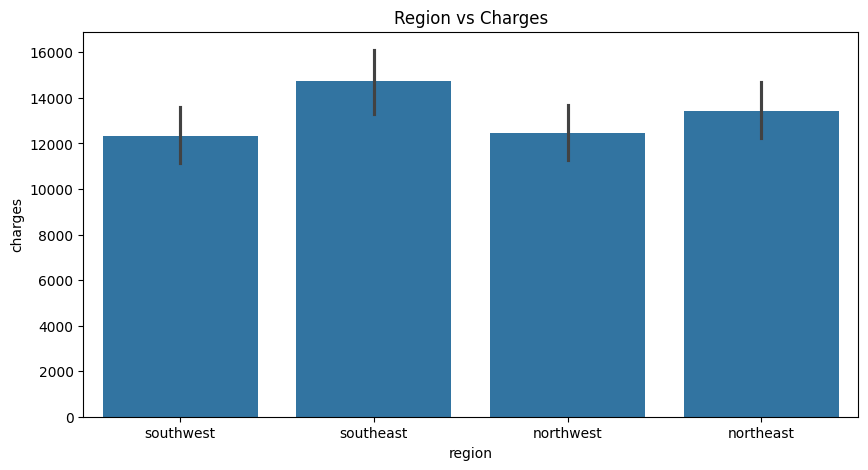

In [18]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="region",
    y="charges",
    data=df
)

plt.title("Region vs Charges")

plt.show()

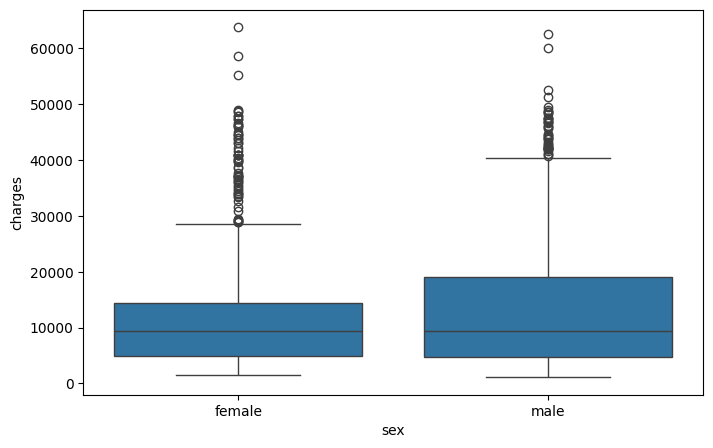

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="sex",
    y="charges",
    data=df
)

plt.show()

In [20]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

corr = numeric_df.corr()

corr

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


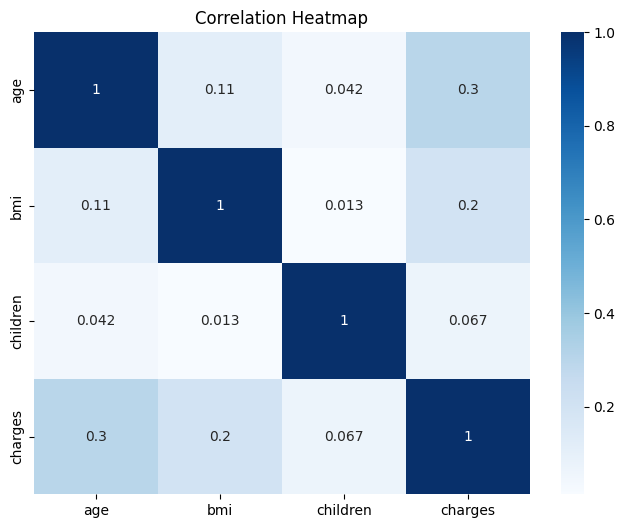

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

In [22]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "sex",
        "smoker",
        "region"
    ],
    drop_first=True
)

df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [23]:
df_encoded.to_csv(
    "../data/cleaned_insurance.csv",
    index=False
)

In [24]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(
    "charges",
    axis=1
)

y = df_encoded["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
predictions = model.predict(
    X_test
)

In [27]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 2611.273683215485
RMSE: 4664.686755872737
R2  : 0.8815859348971048


In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
4,smoker_yes,0.599299
1,bmi,0.216198
0,age,0.137246
2,children,0.022966
3,sex_male,0.006893
5,region_northwest,0.006603
6,region_southeast,0.006241
7,region_southwest,0.004554


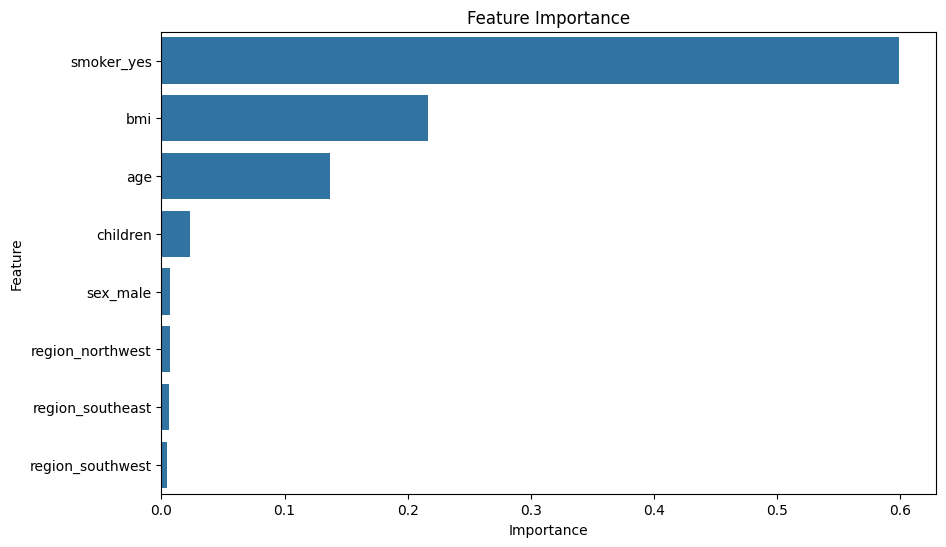

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()